   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 23.2 MB/s eta 0:00:00


In [3]:
import os
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import lime
from lime import lime_image
import shap
from captum.attr import IntegratedGradients
from skimage.segmentation import mark_boundaries

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Loading the dataset

In [4]:
DATA_ROOT  = "/kaggle/input/datasets/aligamalllll/adnii-data/adni_nifti_preprocessed"
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
all_paths  = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f"\nTotal images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Classes found: ['AD', 'CN', 'MCI']

Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


In [5]:
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE = 224
TRAIN_RATIO = 0.80
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
PATIENCE = 10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [6]:
all_paths = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")
print(f"Number of classes: {len(CLASS_NAMES)}")

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f"\nTotal images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Classes found: ['AD', 'CN', 'MCI']
Number of classes: 3

Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


# Splitting (Train, Validation, and Test)

In [7]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")


Train: 6809 | Val: 851 | Test: 852


In [8]:
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

overlap_train_val = len(train_set & val_set)
overlap_train_test = len(train_set & test_set)
overlap_val_test = len(val_set & test_set)

print(f"Train-Val overlap: {overlap_train_val}")
print(f"Train-Test overlap: {overlap_train_test}")
print(f"Val-Test overlap: {overlap_val_test}")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print("✓ No data leakage")
else:
    print("✗ Data leakage detected!")

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
✓ No data leakage


In [9]:
print("\nClass distribution:")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}: {dict(sorted(c.items()))}")


Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


# Saving Tensors

In [10]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)

    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base_fname = os.path.splitext(os.path.basename(path))[0]
        tracking_key = f"{cls_name}_{base_fname}"

        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique_fname = f"{base_fname}_dup{filename_usage[tracking_key]}.pt"
        else:
            filename_usage[tracking_key] = 0
            unique_fname = f"{base_fname}.pt"

        out_path = os.path.join(out_dir, unique_fname)

        img = Image.open(path).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = transforms.ToTensor()(img)
        tensor = (tensor * 255).byte()
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths, val_labels, "val")
save_tensors(test_paths, test_labels, "test")

print("All tensors saved.")

Saving test: 100%|██████████| 852/852 [00:05<00:00, 148.97it/s]

All tensors saved.


# Dataset Class

In [11]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self):
        return [s[1] for s in self.samples]

In [12]:
train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"), CLASS_NAMES)
test_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"), CLASS_NAMES)

print(f"\nDataset sizes:")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Dataset sizes:
Train: 6809 | Val: 851 | Test: 852


# Weighted Sampling For Class Imbalance

In [13]:
train_labels_list = train_ds.get_labels()
class_counts = Counter(train_labels_list)
print(f"\nTraining class distribution: {dict(sorted(class_counts.items()))}")


Training class distribution: {0: 1147, 1: 1873, 2: 3789}


In [14]:
sample_weights = [1.0 / class_counts[label] for label in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Model

In [15]:
def build_paper_cnn_multiclass(num_classes):
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(32),
        
        nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(32),
        
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(32),
        
        nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(32),
        
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        nn.Flatten(),
        nn.Linear(32 * 56 * 56, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        
        nn.Linear(128, 64),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        
        nn.Linear(64, num_classes)
    )
    
    return model

In [16]:
model = build_paper_cnn_multiclass(num_classes=len(CLASS_NAMES)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)
scaler = torch.amp.GradScaler()

print(f"\nModel initialized with {len(CLASS_NAMES)} output classes")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model initialized with 3 output classes
Total parameters: 12,882,531


# Training

In [17]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    """Run one epoch of training or validation"""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

In [18]:
from sklearn.metrics import precision_recall_fscore_support

ckpt_path = os.path.join(CKPT_DIR, "best_densenet_multiclass.pt")

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_ctr = 0

print(f"\n{'='*60}")
print(f"  TRAINING MULTI-CLASS CLASSIFIER")
print(f"  Classes: {CLASS_NAMES}")
print(f"{'='*60}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(
        train_loader, model, criterion, optimizer, scaler,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]"
    )

    vl_loss, vl_acc, val_preds, val_labels = run_epoch(
        val_loader, model, criterion,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]"
    )

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_labels, val_preds, average=None, zero_division=0
    )

    print(f"Epoch {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | "
          f"val loss={vl_loss:.4f} acc={vl_acc*100:.2f}%")
    print(f"  Val per-class F1: {[f'{f:.3f}' for f in f1]}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
        print(f"  ✓ Best val_acc={best_val_acc*100:.2f}% — saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")


  TRAINING MULTI-CLASS CLASSIFIER
  Classes: ['AD', 'CN', 'MCI']



Epoch 01 | train loss=1.1074 acc=36.86% | val loss=1.1214 acc=16.80%
  Val per-class F1: ['0.288', '0.000', '0.000']
  ✓ Best val_acc=16.80% — saved.


Epoch 02 | train loss=1.0753 acc=39.73% | val loss=1.0079 acc=53.47%
  Val per-class F1: ['0.000', '0.469', '0.641']
  ✓ Best val_acc=53.47% — saved.


Epoch 03 | train loss=1.0338 acc=44.46% | val loss=1.0470 acc=47.59%
  Val per-class F1: ['0.401', '0.482', '0.512']


Epoch 04 | train loss=0.9754 acc=49.42% | val loss=0.9431 acc=49.59%
  Val per-class F1: ['0.470', '0.531', '0.487']


...

Epoch 36 | train loss=0.1394 acc=95.26% | val loss=0.0695 acc=97.65%
  Val per-class F1: ['0.990', '0.961', '0.980']


Epoch 37 | train loss=0.1454 acc=94.93% | val loss=0.0871 acc=97.06%
  Val per-class F1: ['0.969', '0.967', '0.973']


Epoch 38 | train loss=0.1295 acc=95.30% | val loss=0.0433 acc=98.47%
  Val per-class F1: ['0.986', '0.981', '0.986']
  ✓ Best val_acc=98.47% — saved.


Epoch 39 | train loss=0.1465 acc=94.87% | val loss=0.0656 acc=97.41%
  Val per-class F1: ['0.976', '0.968', '0.977']


Epoch 40 | train loss=0.1247 acc=95.54% | val loss=0.1238 acc=95.89%
  Val per-class F1: ['1.000', '0.930', '0.962']

Best validation accuracy: 98.47%


# Curves

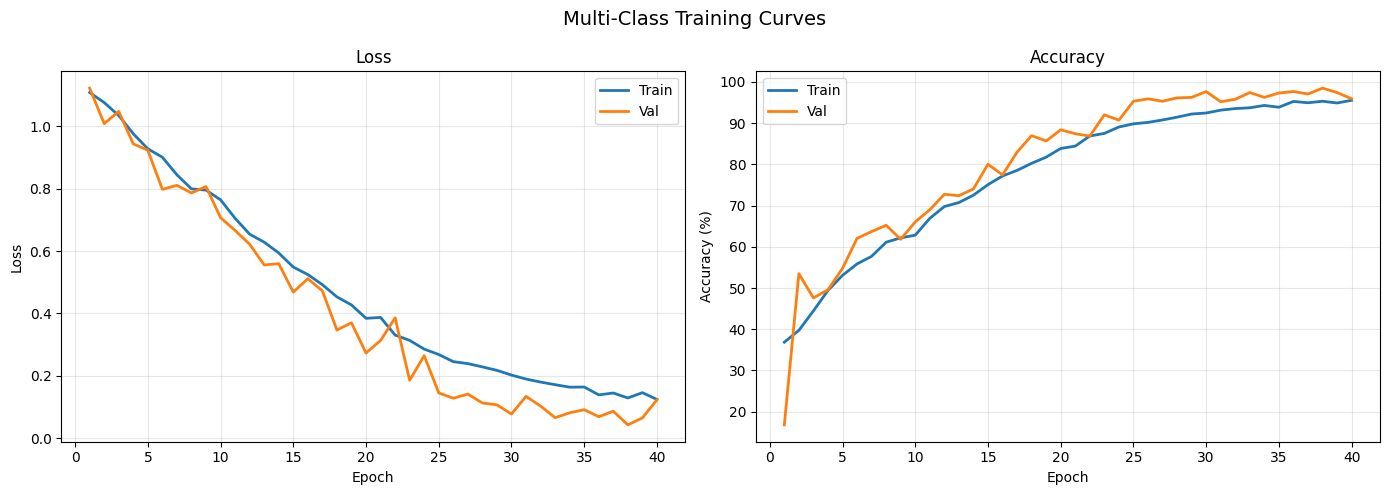

In [19]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multi-Class Training Curves', fontsize=14)

axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']], label='Val', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "curves_multiclass.png"), dpi=150)
plt.show()

# Test Evaluation

In [20]:
print(f"\n{'='*60}")
print(f"  TEST EVALUATION")
print(f"{'='*60}\n")

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

test_loss, test_acc, test_preds, test_labels = run_epoch(
    test_loader, model, criterion, desc="Testing"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%\n")


  TEST EVALUATION



Test Loss: 0.0364
Test Accuracy: 99.30%



# Classification Report

In [21]:
print("Classification Report:")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0
)

print("\nPer-Class Metrics Summary:")
print("-"*60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:15s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | "
          f"F1: {f1[i]:.4f} | Support: {support[i]}")

macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
print(f"\nMacro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

          AD     0.9863    1.0000    0.9931       144
          CN     0.9832    1.0000    0.9915       234
         MCI     1.0000    0.9873    0.9936       474

    accuracy                         0.9930       852
   macro avg     0.9898    0.9958    0.9928       852
weighted avg     0.9931    0.9930    0.9930       852


Per-Class Metrics Summary:
------------------------------------------------------------
AD              | Precision: 0.9863 | Recall: 1.0000 | F1: 0.9931 | Support: 144
CN              | Precision: 0.9832 | Recall: 1.0000 | F1: 0.9915 | Support: 234
MCI             | Precision: 1.0000 | Recall: 0.9873 | F1: 0.9936 | Support: 474

Macro F1-Score: 0.9928
Weighted F1-Score: 0.9930


# Confusion Matrix

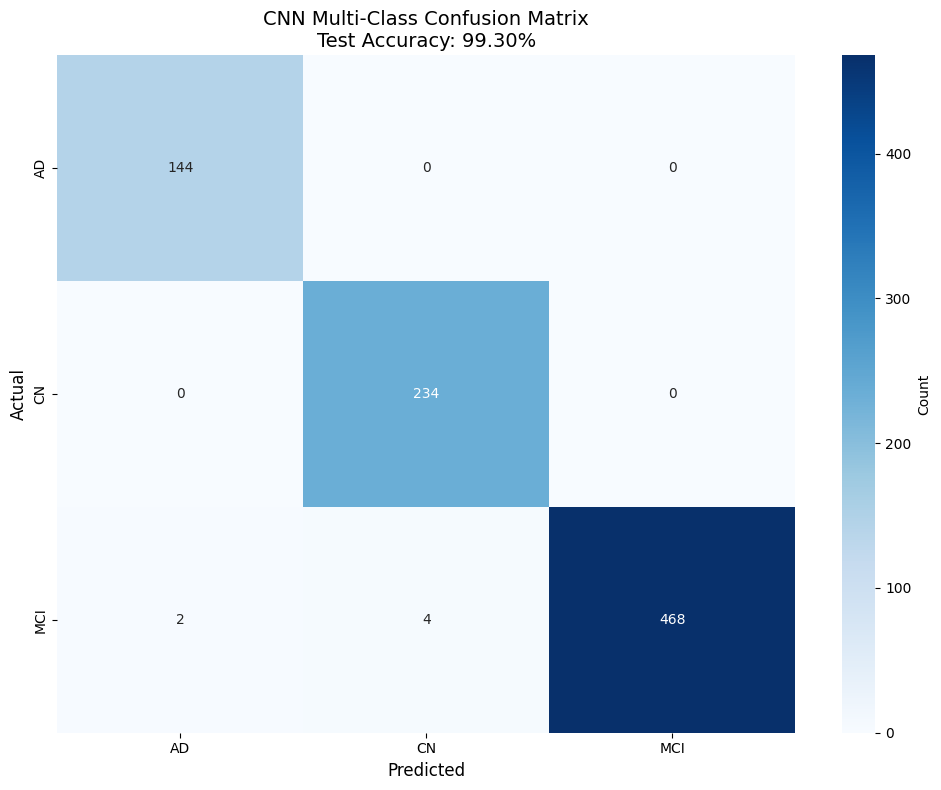

In [22]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'CNN Multi-Class Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_multiclass.png"), dpi=150)
plt.show()

# Saving Results

In [23]:
results = {
    'model': 'cnn',
    'num_classes': len(CLASS_NAMES),
    'class_names': CLASS_NAMES,
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_metrics': {
        cls: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1': float(f1[i]),
            'support': int(support[i])
        }
        for i, cls in enumerate(CLASS_NAMES)
    },
    'confusion_matrix': cm.tolist(),
    'best_val_acc': float(best_val_acc),
    'hyperparameters': {
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LR,
        'momentum': MOMENTUM,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': len(history['train_loss']),
        'patience': PATIENCE
    }
}

results_path = os.path.join(CKPT_DIR, "multiclass_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Results saved to: {results_path}")
print(f"✓ Model checkpoint saved to: {ckpt_path}")

print("\n" + "="*60)
print("  TRAINING COMPLETE")
print("="*60)


✓ Results saved to: /kaggle/working/checkpoints/multiclass_results.json
✓ Model checkpoint saved to: /kaggle/working/checkpoints/best_densenet_multiclass.pt

  TRAINING COMPLETE


XAI 


In [24]:
!pip install grad-cam
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.7 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5787ab88b51bd1ad2923d3aed4b41466b8b13f39c725a57652bec8a1272c966d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [35]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from PIL import Image
from scipy.ndimage import zoom
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import DataLoader
 
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
 
from lime import lime_image
try:
    from lime.wrappers.scikitimage import SegmentationAlgorithm
except (ImportError, ModuleNotFoundError):
    from skimage import segmentation as seg
    class SegmentationAlgorithm:
        def __init__(self, name, **kwargs):
            self.name = name
            self.kwargs = kwargs
        
        def __call__(self, image):
            if self.name == 'slic':
                return seg.slic(image, **self.kwargs)
            else:
                return seg.slic(image, **self.kwargs)
 
from captum.attr import IntegratedGradients
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
 
print(f"Device: {device}")

Device: cuda


In [38]:
def normalize_image(image_array):
    """Normalize image to 0-1 range"""
    if isinstance(image_array, torch.Tensor):
        image_array = image_array.cpu().numpy()
    
    img_min = image_array.min()
    img_max = image_array.max()
    
    if img_max - img_min == 0:
        return np.zeros_like(image_array)
    
    return (image_array - img_min) / (img_max - img_min + 1e-6)

In [37]:
def convert_to_rgb(image_array):
    if len(image_array.shape) == 2:
        return np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[0] == 3:
        return np.transpose(image_array, (1, 2, 0))
    else:
        return image_array

In [39]:
def create_colormap_overlay(heatmap, image_array, alpha=0.4, colormap='jet'):
    """Create overlay of heatmap on image"""
    heatmap = normalize_image(heatmap)
    image_array = normalize_image(image_array)
    
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    
    heatmap_colored = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8),
        cv2.COLORMAP_JET if colormap == 'jet' else cv2.COLORMAP_HOT
    ) / 255.0
    
    overlay = image_array * (1 - alpha) + heatmap_colored * alpha
    
    return np.clip(overlay, 0, 1)

In [57]:
def compute_gradcam(model, image_tensor, target_class, device='cuda'):
    model = model.to(device)
    model.eval()
    
    conv_layers = []
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append(module)
    
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model")
    
    target_layers = [conv_layers[-1]]
    
    cam = GradCAM(
        model=model,
        target_layers=target_layers,
    )
    
    image_tensor = image_tensor.to(device)
    targets = [ClassifierOutputTarget(target_class)]
    
    grayscale_cam = cam(
        input_tensor=image_tensor,
        targets=targets,
        eigen_smooth=False,
        aug_smooth=False
    )
    
    with torch.no_grad():
        output = model(image_tensor)
        pred_probs = torch.softmax(output, dim=1)[0]
        pred_class = output.argmax(dim=1).item()
        pred_prob = pred_probs[target_class].item()
    
    return grayscale_cam[0], pred_class, pred_prob

In [44]:
def visualize_gradcam(image_array, grayscale_cam, pred_class, pred_prob, 
                     target_class, class_names=None, title="Grad-CAM"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    
    grayscale_cam = normalize_image(grayscale_cam)
    
    axes[0].imshow(image_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im = axes[1].imshow(grayscale_cam, cmap='hot')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    overlay = create_colormap_overlay(grayscale_cam, image_array, alpha=0.5, colormap='jet')
    axes[2].imshow(overlay)
    
    class_str = class_names[target_class] if class_names else f"Class {target_class}"
    pred_str = class_names[pred_class] if class_names else f"Class {pred_class}"
    axes[2].set_title(f'Overlay\n(Target: {class_str}, Pred: {pred_str} {pred_prob:.2%})')
    axes[2].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

In [63]:
def compute_lime_explanation(model, image_array, target_class, device='cuda',
                           num_samples=1000, num_features=10):
    model = model.to(device)
    model.eval()
    
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    
    def predict_fn(images):
        if isinstance(images, np.ndarray):
            images = torch.from_numpy(images).float()
        
        if images.ndim == 3:
            images = images.unsqueeze(0)
        
        if images.shape[-1] in (1, 3):
            images = images.permute(0, 3, 1, 2)
        
        images = images.to(device)
        
        with torch.no_grad():
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        
        return probs.cpu().numpy()

    try:
        explainer = lime_image.LimeImageExplainer()
        
        try:
            seg_algo = SegmentationAlgorithm('slic', n_segments=50, compactness=10)
        except:
            seg_algo = None
        
        if seg_algo:
            explanation = explainer.explain_instance(
                image=image_array,
                classifier_fn=predict_fn,
                labels=[target_class],
                top_labels=None,
                num_samples=num_samples,
                segmentation_fn=seg_algo)

        else:
            explanation = explainer.explain_instance(
                image=image_array,
                classifier_fn=predict_fn,
                labels=[target_class],
                top_labels=None,
                num_samples=num_samples)

        image_and_mask = explanation.get_image_and_mask(
            label=target_class,
            positive_only=False,
            num_features=num_features,
            hide_rest=False)
        
        return explanation, image_and_mask
    
    except Exception as e:
        print(f"Warning: LIME encountered error: {e}")
        print("Returning simplified LIME output")
        
        return None, (image_array, np.zeros_like(image_array[:,:,0]))

In [46]:
def visualize_lime(image_array, explanation, image_and_mask, target_class,
                  class_names=None, title="LIME Explanation"):

    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    
    image, mask = image_and_mask
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(image_array, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(image)
    axes[0, 1].set_title('Superpixel Segmentation')
    axes[0, 1].axis('off')
    
    if explanation is not None:
        try:
            pos_image, _ = explanation.get_image_and_mask(
                label=target_class,
                positive_only=True,
                hide_rest=False)
        except:
            pos_image = image
    else:
        pos_image = image
    
    axes[1, 0].imshow(pos_image)
    class_str = class_names[target_class] if class_names else f"Class {target_class}"
    axes[1, 0].set_title(f'Supporting Regions ({class_str})')
    axes[1, 0].axis('off')
    
    if explanation is not None:
        try:
            features_weights = sorted(
                explanation.local_exp[target_class],
                key=lambda x: x[1],
                reverse=True
            )[:10]
            
            feature_ids = [f[0] for f in features_weights]
            weights = [f[1] for f in features_weights]
            
            axes[1, 1].barh(range(len(weights)), weights, color='steelblue')
            axes[1, 1].set_yticks(range(len(weights)))
            axes[1, 1].set_yticklabels([f'Region {i}' for i in feature_ids])
            axes[1, 1].set_xlabel('Weight')
            axes[1, 1].set_title('Feature Importance')
            axes[1, 1].invert_yaxis()
        except:
            axes[1, 1].text(0.5, 0.5, 'LIME features\nnot available', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].axis('off')
    else:
        axes[1, 1].text(0.5, 0.5, 'LIME computation\nfailed', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

In [68]:
def compute_integrated_gradients(model, image_tensor, target_class, device='cuda',
                                n_steps=50, baseline=None):
    model = model.to(device)
    model.eval()
    
    image_tensor = image_tensor.to(device)
    
    if baseline is None:
        baseline = torch.zeros_like(image_tensor).to(device)
    else:
        baseline = baseline.to(device)
    
    ig = IntegratedGradients(model)
    
    attributions = ig.attribute(
        image_tensor,
        baselines=baseline,
        target=target_class,
        n_steps=n_steps,
        return_convergence_delta=False)
    
    attributions = attributions.squeeze(0)
    
    with torch.no_grad():
        output = model(image_tensor)
        pred_probs = torch.softmax(output, dim=1)[0]
        pred_class = output.argmax(dim=1).item()
        pred_prob = pred_probs[target_class].item()
    
    return attributions.detach().cpu(), pred_class, pred_prob

In [69]:
def visualize_integrated_gradients(image_array, attributions, pred_class, pred_prob,
                                  target_class, class_names=None, title="Integrated Gradients"):
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    elif image_array.shape[0] == 3:
        image_array = np.transpose(image_array, (1, 2, 0))
    
    if attributions.shape[0] == 3:
        attr_map = attributions.mean(dim=0).numpy()
        attr_signed = attributions.permute(1, 2, 0).mean(dim=-1).numpy()
    else:
        attr_map = attributions[0].numpy()
        attr_signed = attr_map
    
    attr_map_norm = normalize_image(attr_map)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(image_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im1 = axes[1].imshow(attr_map_norm, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Attribution Magnitude')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    im2 = axes[2].imshow(attr_signed, cmap='RdBu',
                         vmin=-np.abs(attr_signed).max(),
                         vmax=np.abs(attr_signed).max())
    axes[2].set_title('Signed Attribution\n(Red=Support, Blue=Against)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    
    overlay = create_colormap_overlay(attr_map_norm, image_array, alpha=0.5, colormap='hot')
    axes[3].imshow(overlay)
    class_str = class_names[target_class] if class_names else f"Class {target_class}"
    pred_str = class_names[pred_class] if class_names else f"Class {pred_class}"
    axes[3].set_title(f'Overlay\n(Target: {class_str}, Pred: {pred_str} {pred_prob:.2%})')
    axes[3].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

In [49]:
def compute_occlusion_sensitivity(model, image_tensor, target_class, device='cuda',
                                 patch_size=32, stride=16):
    model = model.to(device)
    model.eval()
    
    batch_size, channels, height, width = image_tensor.shape
    image_tensor = image_tensor.to(device)
    
    with torch.no_grad():
        original_output = model(image_tensor)
        original_prob = torch.softmax(original_output, dim=1)[0, target_class].item()
    
    sensitivity_map = np.zeros(
        (height // stride, width // stride) )
    
    for i in tqdm(range(0, height - patch_size, stride), desc="Computing Occlusion"):
        for j in range(0, width - patch_size, stride):
            occluded_image = image_tensor.clone()
            occluded_image[
                :, :,
                i:i+patch_size,
                j:j+patch_size
            ] = 0  
            
            with torch.no_grad():
                occluded_output = model(occluded_image)
                occluded_prob = torch.softmax(occluded_output, dim=1)[0, target_class].item()
            
            sensitivity = original_prob - occluded_prob
            sensitivity_map[i // stride, j // stride] = max(0, sensitivity)
    
    return sensitivity_map, original_prob

In [50]:
def visualize_occlusion_sensitivity(image_array, sensitivity_map, original_prob,
                                   pred_class, target_class, class_names=None,
                                   title="Occlusion Sensitivity"):
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2:
        image_array = convert_to_rgb(image_array)
    
    image_size = image_array.shape[0]
    sensitivity_resized = zoom(
        sensitivity_map,
        (image_size / sensitivity_map.shape[0],
         image_size / sensitivity_map.shape[1]),
        order=1)
    
    sensitivity_resized = normalize_image(sensitivity_resized)
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    axes[0].imshow(image_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im = axes[1].imshow(sensitivity_resized, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Occlusion Sensitivity\n(Darker = More Important)')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], label='Prediction Drop', fraction=0.046, pad=0.04)
    
    overlay = create_colormap_overlay(sensitivity_resized, image_array, alpha=0.5, colormap='jet')
    axes[2].imshow(overlay)
    class_str = class_names[target_class] if class_names else f"Class {target_class}"
    pred_str = class_names[pred_class] if class_names else f"Class {pred_class}"
    axes[2].set_title(f'Overlay\n(Pred: {pred_str}, Orig Prob: {original_prob:.2%})')
    axes[2].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = ['CN', 'MCI', 'AD']
print(f"Device: {device}")
print("XAI functions ready!")

Device: cuda
XAI functions ready!


In [53]:
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f'Model loaded from: {ckpt_path}')
print(f'Classes: {CLASS_NAMES}')

Model loaded from: /kaggle/working/checkpoints/best_densenet_multiclass.pt
Classes: ['AD', 'CN', 'MCI']


In [54]:
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(tensor):
    t = tensor.cpu().clone()
    t = t * IMAGENET_STD_T + IMAGENET_MEAN_T
    t = t.clamp(0, 1)
    return t.permute(1, 2, 0).numpy()

xai_samples = {} 

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(1)
        for i in range(len(labels)):
            cls_idx = labels[i].item()
            if cls_idx not in xai_samples and preds[i].item() == cls_idx:
                img_tensor = images[i].unsqueeze(0).cpu()
                img_array  = denormalize(images[i].cpu())
                xai_samples[cls_idx] = (img_tensor, img_array)
        if len(xai_samples) == len(CLASS_NAMES):
            break

print(f'Collected {len(xai_samples)} samples (one per class):')
for idx in sorted(xai_samples):
    print(f'  Class {idx}: {CLASS_NAMES[idx]}')

Collected 3 samples (one per class):
  Class 0: AD
  Class 1: CN
  Class 2: MCI


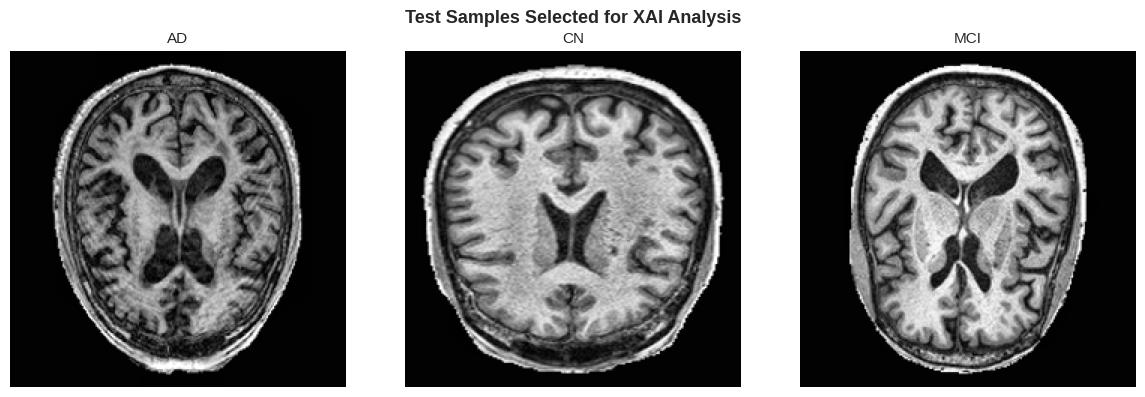

In [55]:
n = len(xai_samples)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, (cls_idx, (_, img_arr)) in zip(axes, sorted(xai_samples.items())):
    ax.imshow(img_arr)
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=11)
    ax.axis('off')

fig.suptitle('Test Samples Selected for XAI Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'xai_selected_samples.png'), dpi=150)
plt.show()


[Grad-CAM] Class: AD


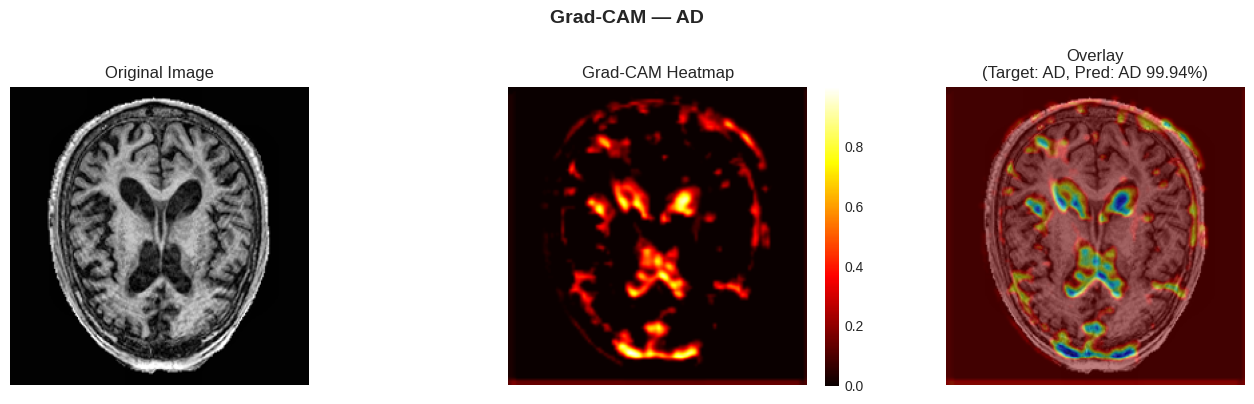

  Predicted: AD (99.94%)

[Grad-CAM] Class: CN


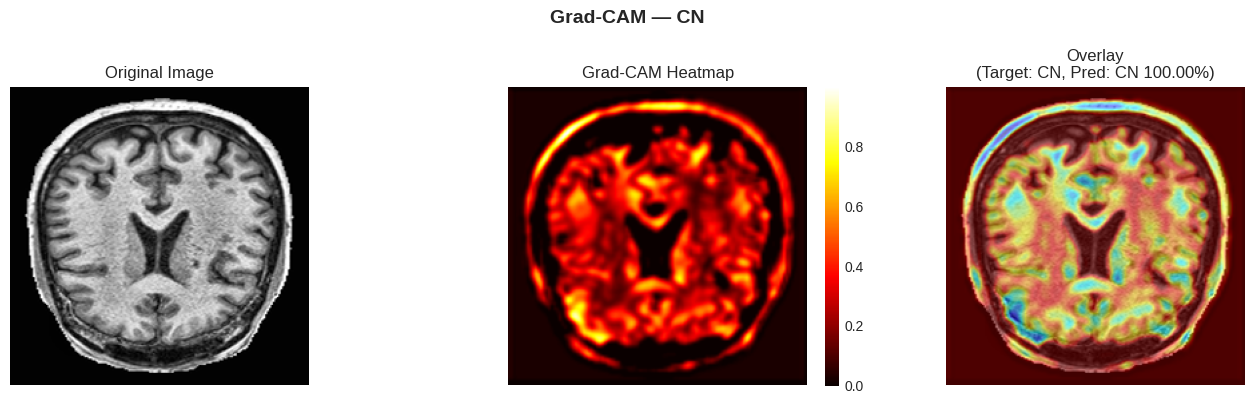

  Predicted: CN (100.00%)

[Grad-CAM] Class: MCI


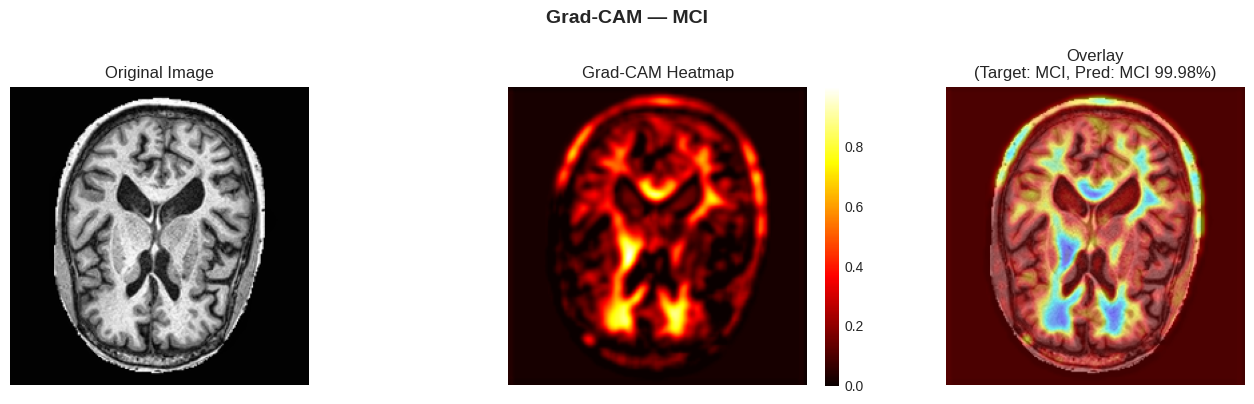

  Predicted: MCI (99.98%)


In [58]:
gradcam_results = {}

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    print(f'\n[Grad-CAM] Class: {CLASS_NAMES[cls_idx]}')

    try:
        cam, pred_class, pred_prob = compute_gradcam(
            model, img_tensor, cls_idx, device)
        fig = visualize_gradcam(
            img_array, cam, pred_class, pred_prob, cls_idx,
            class_names=CLASS_NAMES,
            title=f'Grad-CAM — {CLASS_NAMES[cls_idx]}')
        save_path = os.path.join(CKPT_DIR, f'gradcam_{CLASS_NAMES[cls_idx]}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        gradcam_results[cls_idx] = {'heatmap': cam, 'pred_class': pred_class, 'pred_prob': pred_prob}
        print(f'  Predicted: {CLASS_NAMES[pred_class]} ({pred_prob:.2%})')
    except Exception as e:
        print(f'  ERROR: {e}')


[LIME] Class: AD


  0%|          | 0/1000 [00:00<?, ?it/s]

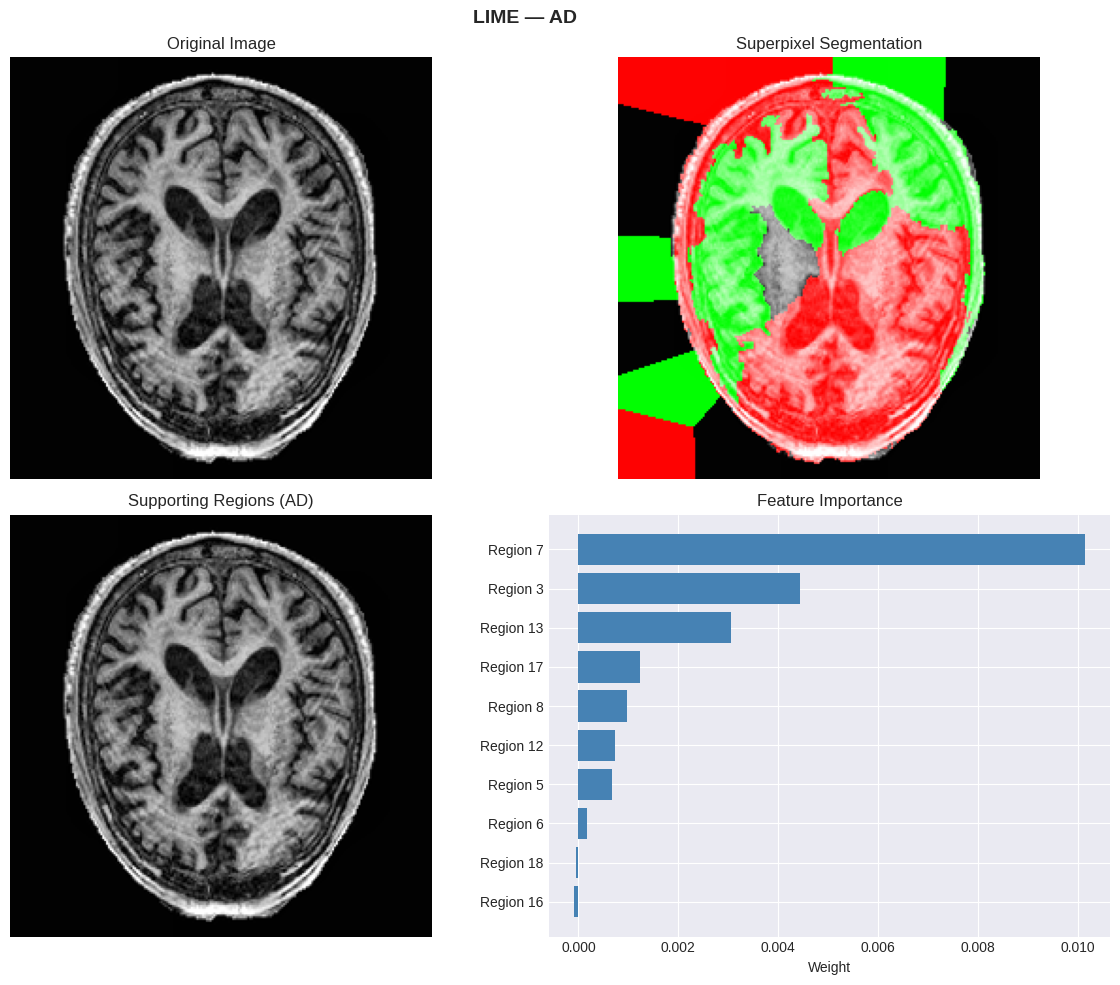

  ✓ LIME saved to /kaggle/working/checkpoints/lime_AD.png

[LIME] Class: CN


  0%|          | 0/1000 [00:00<?, ?it/s]

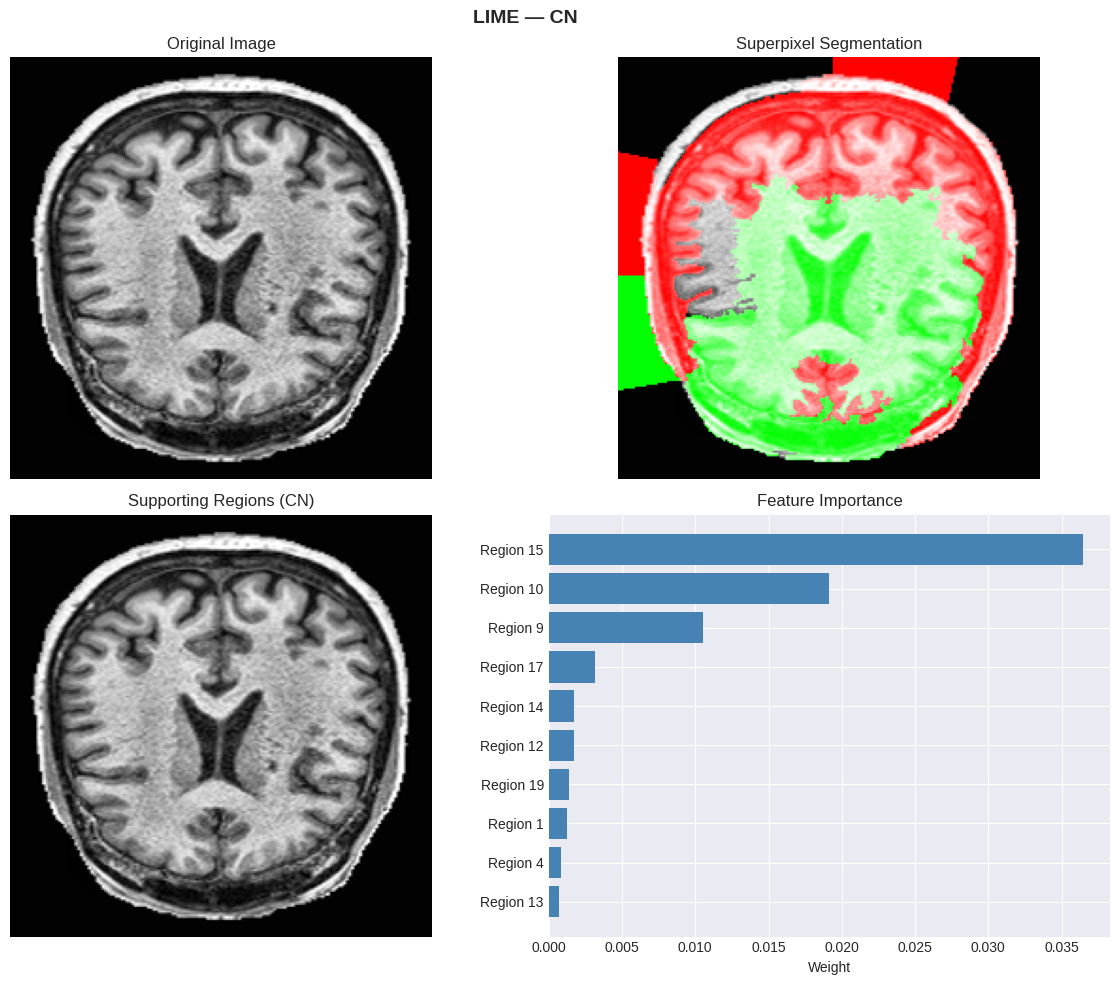

  ✓ LIME saved to /kaggle/working/checkpoints/lime_CN.png

[LIME] Class: MCI


  0%|          | 0/1000 [00:00<?, ?it/s]

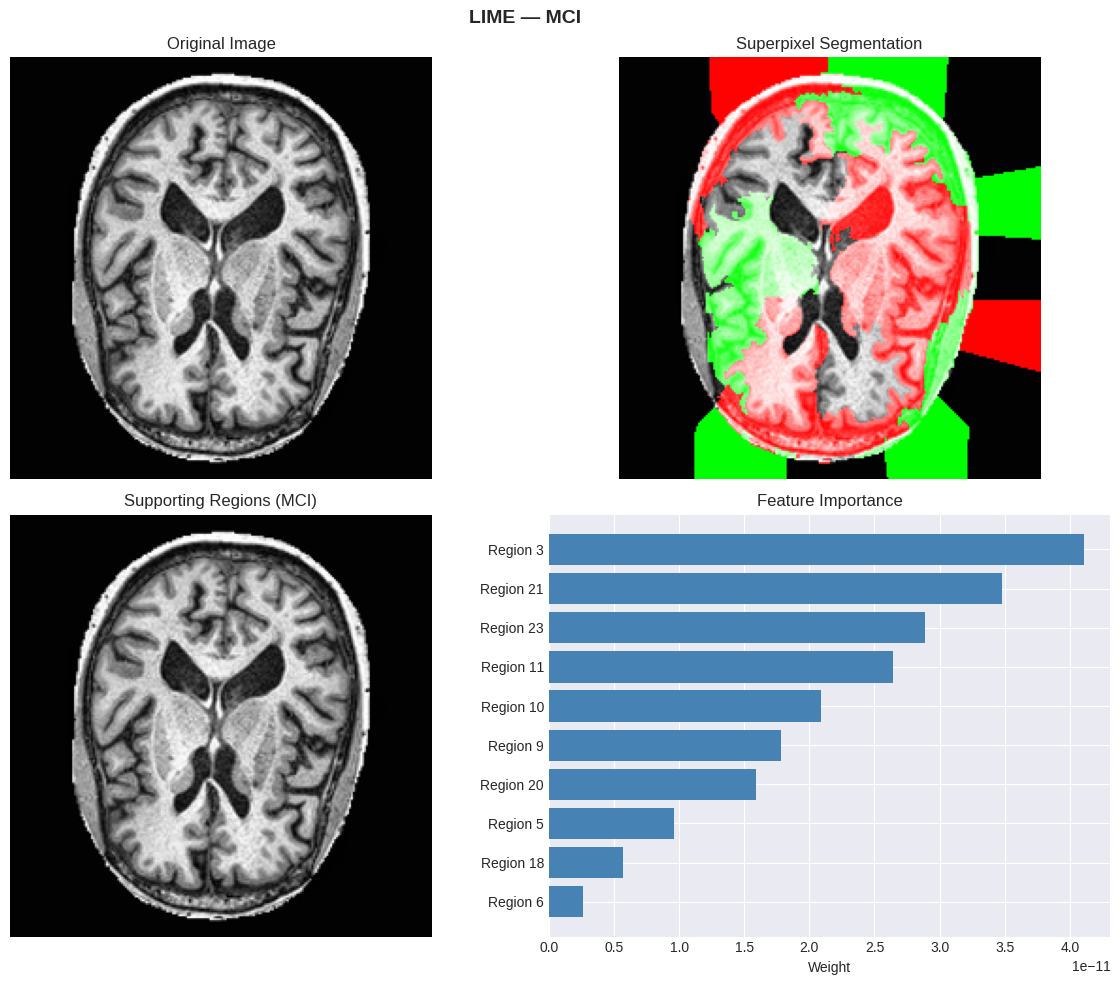

  ✓ LIME saved to /kaggle/working/checkpoints/lime_MCI.png


In [64]:
LIME_QUICK = False
lime_results = {}

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    print(f'\n[LIME] Class: {CLASS_NAMES[cls_idx]}')

    try:
        n_samples = 500 if LIME_QUICK else 1000
        explanation, img_and_mask = compute_lime_explanation(
            model, img_array, cls_idx, device=device,
            num_samples=n_samples, num_features=10
        )
        fig = visualize_lime(
            img_array, explanation, img_and_mask, cls_idx,
            class_names=CLASS_NAMES,
            title=f'LIME — {CLASS_NAMES[cls_idx]}'
        )
        save_path = os.path.join(CKPT_DIR, f'lime_{CLASS_NAMES[cls_idx]}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        lime_results[cls_idx] = {'explanation': explanation, 'image_and_mask': img_and_mask}
        print(f'  ✓ LIME saved to {save_path}')
    except Exception as e:
        print(f'  ERROR: {e}')


[Integrated Gradients] Class: AD


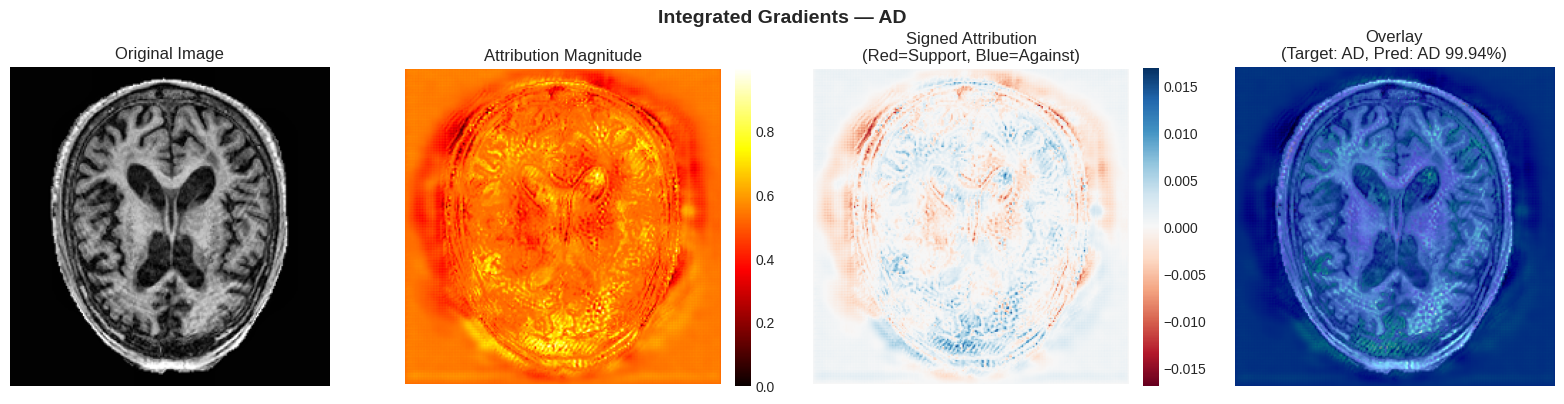

  Predicted: AD (99.94%)

[Integrated Gradients] Class: CN


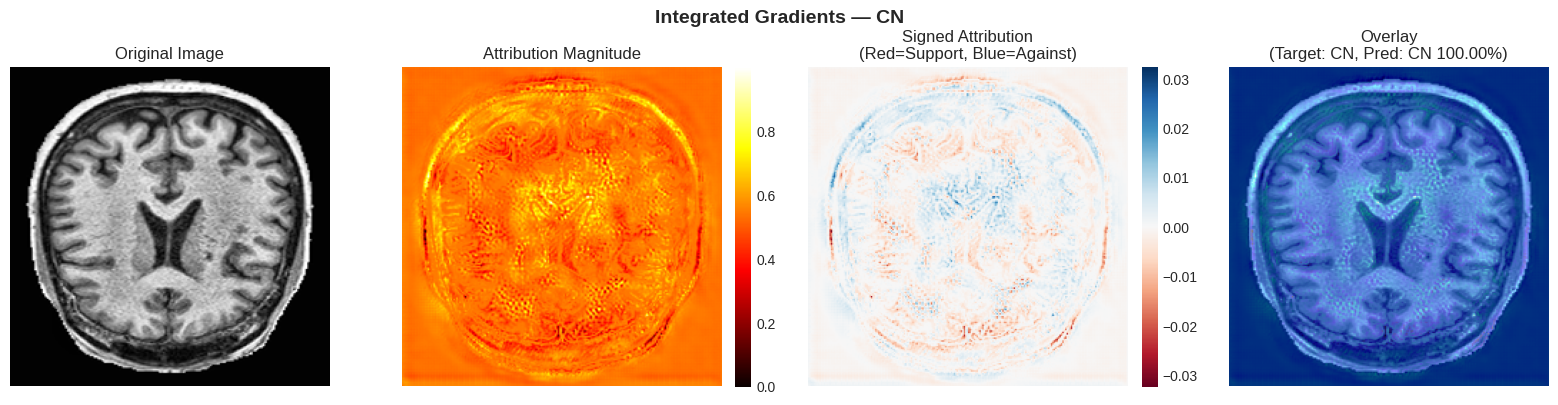

  Predicted: CN (100.00%)

[Integrated Gradients] Class: MCI


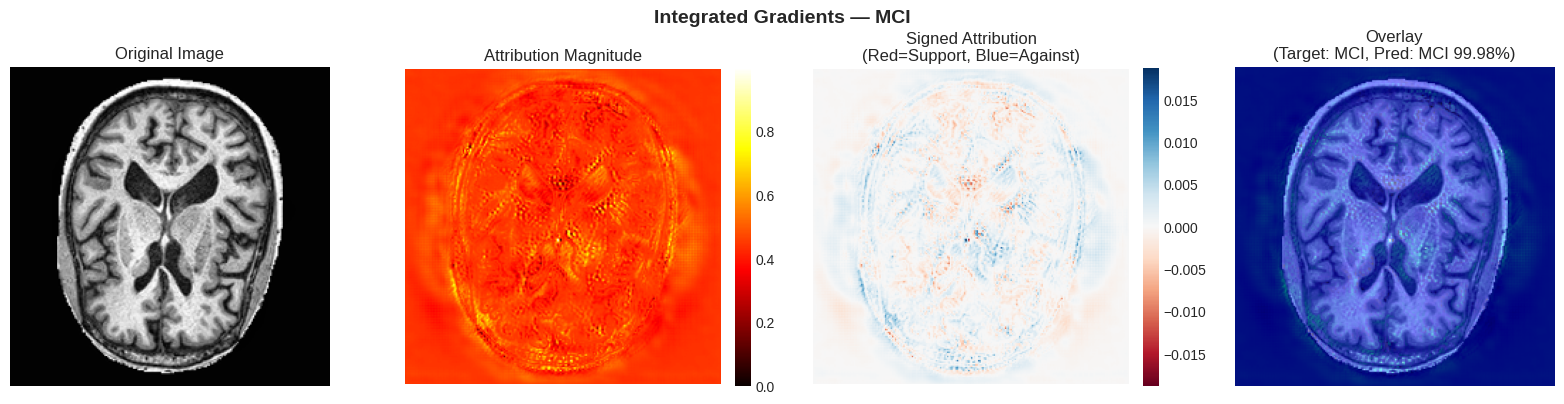

  Predicted: MCI (99.98%)


In [70]:
ig_results = {}

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    print(f'\n[Integrated Gradients] Class: {CLASS_NAMES[cls_idx]}')

    try:
        attributions, pred_class, pred_prob = compute_integrated_gradients(
            model, img_tensor, cls_idx, device=device, n_steps=50
        )
        fig = visualize_integrated_gradients(
            img_array, attributions, pred_class, pred_prob, cls_idx,
            class_names=CLASS_NAMES,
            title=f'Integrated Gradients — {CLASS_NAMES[cls_idx]}'
        )
        save_path = os.path.join(CKPT_DIR, f'ig_{CLASS_NAMES[cls_idx]}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        ig_results[cls_idx] = {'attributions': attributions, 'pred_class': pred_class, 'pred_prob': pred_prob}
        print(f'  Predicted: {CLASS_NAMES[pred_class]} ({pred_prob:.2%})')
    except Exception as e:
        print(f'  ERROR: {e}')


[Occlusion] Class: AD


Computing Occlusion: 100%|██████████| 12/12 [00:00<00:00, 53.36it/s]


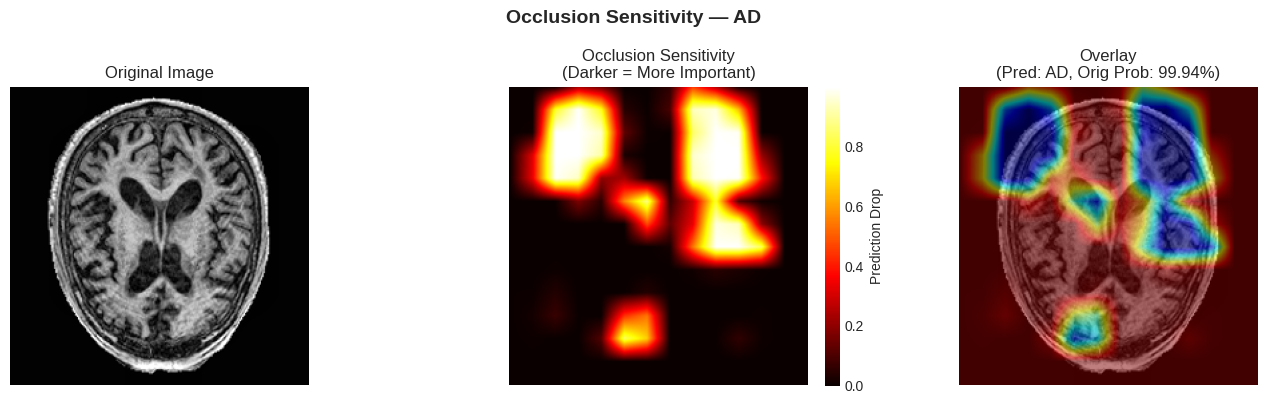

  Orig prob for target class: 99.94%

[Occlusion] Class: CN


Computing Occlusion: 100%|██████████| 12/12 [00:00<00:00, 68.85it/s]


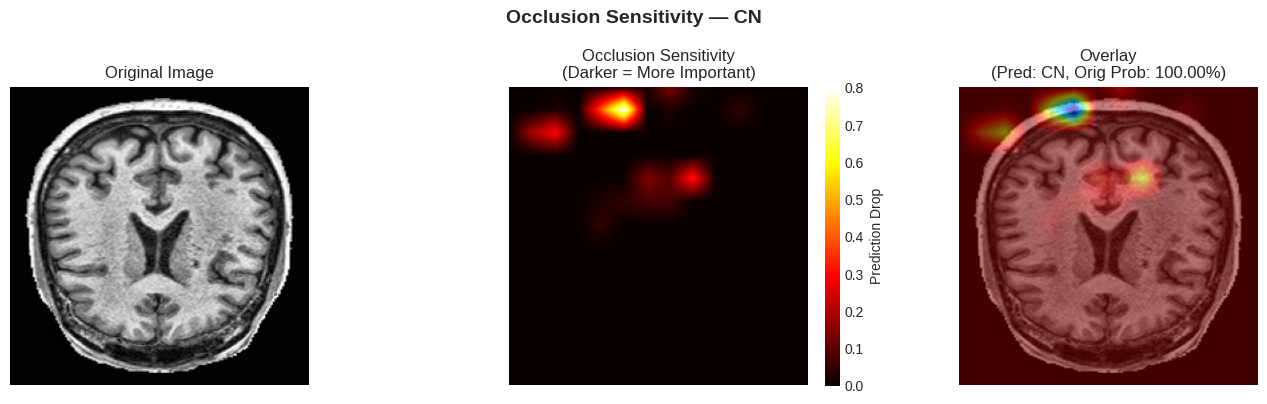

  Orig prob for target class: 100.00%

[Occlusion] Class: MCI


Computing Occlusion: 100%|██████████| 12/12 [00:00<00:00, 68.91it/s]


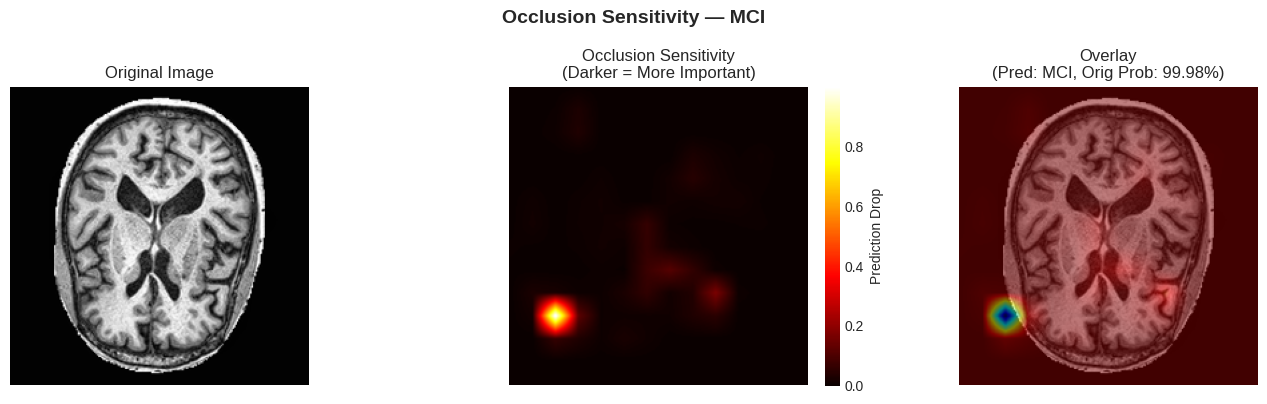

  Orig prob for target class: 99.98%


In [71]:
OCC_PATCH  = 32
OCC_STRIDE = 16
occ_results = {}

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    print(f'\n[Occlusion] Class: {CLASS_NAMES[cls_idx]}')

    try:
        sens_map, orig_prob = compute_occlusion_sensitivity(
            model, img_tensor, cls_idx, device=device,
            patch_size=OCC_PATCH, stride=OCC_STRIDE
        )
        model.eval()
        with torch.no_grad():
            out = model(img_tensor.to(device))
            pred_class = out.argmax(1).item()

        fig = visualize_occlusion_sensitivity(
            img_array, sens_map, orig_prob, pred_class, cls_idx,
            class_names=CLASS_NAMES,
            title=f'Occlusion Sensitivity — {CLASS_NAMES[cls_idx]}'
        )
        save_path = os.path.join(CKPT_DIR, f'occlusion_{CLASS_NAMES[cls_idx]}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        occ_results[cls_idx] = {'sensitivity_map': sens_map, 'original_prob': orig_prob}
        print(f'  Orig prob for target class: {orig_prob:.2%}')
    except Exception as e:
        print(f'  ERROR: {e}')